## Trabalho 2 — INF-0618 Deep Learning   
Alunos:
- Vitor de Oliveira Fernandez Araujo
- Vitor Sancho Cardoso


Neste trabalho, vamos utilizar o conjunto de dados Measuring Hate Speech (Medindo discurso de ódio). Este conjunto de dados foi criado e publicado por Kennedy et al. (2020) e Sachdeva et al. (2022). Os dados coletados são de 3 diferentes redes sociais: Twitter (tweets), Youtube (comentários de vídeos) e Reddit (comentários em posts), entre Março e Agosto de 2019, apenas na lingua inglesa.

O principal rótulo do dataset consiste em "hate speech score", um score de quanto a amostra representa discurso de ódio. Esse score foi construído a partir de outras 10 categorias de discurso de ódio (sentimento, respeito, insulto, humilhação, status, violência, desumanização, genocídio, ataque/defesa, discurso de ódio). Cada amostra foi classificada por diferentes anotadores (ao total 8,472 anotadores). Outras informações como grupos alvo e subgrupos, assim como a demografia dos anotadores, também existem no dataset.
Para uma análise e entendimento melhor da teoria por trás da forma de coleta, recomenda-se o paper "The Measuring Hate Speech Corpus: Leveraging Rasch Measurement Theory for Data Perspectivism".

Para esse trabalho específico, utilizaremos uma versão deste conjunto de dados onde o resultado de "hate speech score" dos diferentes anotadores de cada amostra foram utilizados para construir um score médio, simplificando o problema (ignorando o viés dos anotadores). Desta forma, nosso problema é um problema de **regressão**. Além disso, utilizaremos menos amostras, apenas 27695.

O dataset completo pode ser acessado no link do [hugging face](https://huggingface.co/datasets/ucberkeley-dlab/measuring-hate-speech), enquanto o **dataset que deve ser usado** esta na [mesma pasta compartilhada do trabalho 1 (aqui)](https://drive.google.com/drive/folders/1OYDEVPH52LF0Z4hg5uq3LnvsWB61_5zA?usp=sharing), na pasta "hate_speech_ds".




## Instalação das Bibliotecas

Para instalar as bibliotecas necessárias, execute os comandos abaixo:

In [2]:
# Já instalados no colab, instalar localmente!
# !pip install pandas
# !pip install transformers

# Não instalado no Colab
!pip install bertviz

## Carregar e preparar os dados

O conjunto de dados já vem pré dividido, consistindo nas seguintes colunas:

- **comment_id**: O id da amostra;
- **text**: O conteúdo textual da amostra, retirado do twitter, reddit ou youtube;
- **hate_speech_score**: Um score em ponto flutuante (float) de quanto a amostra se alinha a discurso de ódio (mais positivo), ou a discursos benéficos/não odiosos (negativo).


In [3]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import numpy as np

# Usa uma seed global para o TensorFlow, para resultados reprodutíveis
tf.random.set_seed(42)

In [4]:
import os

PATH = '/tmp/hf_cache'
os.environ['TRANSFORMERS_CACHE'] = PATH
os.environ['HF_HOME'] = PATH
os.environ['HF_DATASETS_CACHE'] = PATH
os.environ['TORCH_HOME'] = PATH

In [5]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
colab_path = "/content/drive/MyDrive/MDC_Datasets/"

In [7]:
from datasets import load_from_disk

ds = load_from_disk(colab_path + "/measuring_hate_speech_custom.hf")
ds

DatasetDict({
    train: Dataset({
        features: ['comment_id', 'text', 'hate_speech_score'],
        num_rows: 11869
    })
    validation: Dataset({
        features: ['comment_id', 'text', 'hate_speech_score'],
        num_rows: 7913
    })
    test: Dataset({
        features: ['comment_id', 'text', 'hate_speech_score'],
        num_rows: 7913
    })
})

In [8]:
# Separa os dados
df_train = ds['train']
df_val = ds['validation']
df_test = ds['test']
del ds # limpa memoria

df_train.shape[0], df_val.shape[0], df_test.shape[0],

(11869, 7913, 7913)

O rótulo do nosso dataset, hate_speech_score, possui um range alto tanto de valores positivos quanto negativos. Isso pode impactar a performance do modelo, portanto precisamos normalizar essa variável antes do treinamento.

In [9]:
print(f'Maior valor de treino: {max([x for x in df_train['hate_speech_score']]):.3f}, e menor valor de treino: {min([x for x in df_train['hate_speech_score']]):.3f}')

Maior valor de treino: 6.300, e menor valor de treino: -8.340


In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

# Transforma em 2D (formato esperado do sklearn scaler)
train_labels = np.array(df_train['hate_speech_score']).reshape(-1, 1)
scaler.fit(train_labels)

# Cria uma função com o scaler para usar o 'map' do Hugging Face
def scale_labels(examples):
  scaled_score = scaler.transform(np.array(examples['hate_speech_score']).reshape(-1, 1))
  # Após o flatten ainda sobra uma dimensão que tem apenas um valor/rótulo
  return {'hate_speech_score': scaled_score.flatten()[0]}

df_train = df_train.map(scale_labels)
df_val = df_val.map(scale_labels)
df_test = df_test.map(scale_labels)

## Exibir uma amostra alta e outra baixa

Este código pega uma amostra com rótulo negativo e outra bem positivo como exemplos


In [11]:
import random
from datasets import Dataset
import datasets
# Tira a barra de progresso momentaneamente
# datasets.disable_progress_bars()

# Coleta uma amostra baixa e outra alta
low_samples = []
high_samples = []
for sample in df_train:
  if sample['hate_speech_score'] < 0.05: # lembrando que esta normalizado entre 0 e 1
    low_samples.append(sample)
  elif sample['hate_speech_score'] > 0.95:
    high_samples.append(sample)

  if len(high_samples) > 0 and len(low_samples)>0:
    break

# Mostra as amostras
print(f'Sample com discurso de ódio\nTexto: {high_samples[0]['text']}\nRótulo: {high_samples[0]['hate_speech_score']}')
print("\n")
print(f'Sample sem discurso de ódio\nTexto: {low_samples[0]['text']}\nRótulo: {low_samples[0]['hate_speech_score']}')

Sample com discurso de ódio
Texto: Dig burn PITS and treat them THE INVADING NAZIS ALL OVER EUROPE. ESPECIALLY THE WOMEN DON'T LET THEM BREED HERE MR. PRESIDENT. FIRING SQUADS SO I CAN VOLUNTEER
Rótulo: 1.0


Sample sem discurso de ódio
Texto: Fellow trans girl here! Love and support confirmed!
Rótulo: 0.0


## Exemplo: Carregar modelo e tokenizer BERT para classificação

Neste exemplo, utilizamos a biblioteca `transformers` para carregar um modelo BERT pré-treinado e o tokenizer correspondente, configurado para uma tarefa de classificação binária. O número de classes é definido como 1, de forma que a função de carregamento entende que é um problema de regressão.

Você pode ajustar o modelo de acordo com sua capacidade computacional. Aqui estão as opções de modelos disponíveis:
- **"prajjwal1/bert-tiny" (~4M)**: Modelo mais leve, ideal para recursos limitados.
- **"prajjwal1/bert-small" (~28M)**: Um pouco maior, ainda eficiente para muitos cenários.
- **"prajjwal1/bert-medium" (~41M)**: Modelo médio, reduzido em mais da metade do tamanho original do BERT.
- **"bert-base-uncased" (~110M)**: Modelo padrão e mais pesado, adequado para máquinas mais potentes (Esse é demorado de rodar no Colab, e precisa de batch size pequeno).

In [12]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

NUM_LABELS = 1
model_name = "prajjwal1/bert-small" # Escolha o modelo conforme sua necessidade
baseline_tokenizer = AutoTokenizer.from_pretrained(model_name)  # Carregar o tokenizer
baseline_model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUM_LABELS, from_pt=True)

/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/116M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should p

In [13]:
baseline_model.summary()

Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  28763648  
                                                                 
 dropout_13 (Dropout)        multiple                  0         
                                                                 
 classifier (Dense)          multiple                  513       
                                                                 
Total params: 28764161 (109.73 MB)
Trainable params: 28764161 (109.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Funções auxiliares

In [28]:
def plot_loss(history):
  history_dict = history.history

  plt.figure(figsize=(14, 5))

  plt.subplot(1, 2, 1)
  plt.plot(history_dict['loss'], label='Training Loss')
  if 'val_loss' in history_dict:
      plt.plot(history_dict['val_loss'], label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.xticks(range(0, len(history_dict['loss'])))
  plt.title('Loss over Epochs')
  plt.legend()

  plt.tight_layout()
  plt.show()

## Atividade

Para o desenvolvimento deste trabalho, siga atentamente as atividades listadas a seguir. Em cada uma delas, espera-se que você apresente uma descrição detalhada dos experimentos realizados, acompanhada de uma discussão aprofundada dos resultados obtidos. Cada atividade possui uma pontuação específica, que será atribuída de acordo com a execução e a qualidade da análise apresentada.

Lembre-se de que a clareza na explicação dos métodos e a precisão na interpretação dos dados são essenciais para a avaliação. Bons resultados são importantes, mas a capacidade de refletir criticamente sobre eles é o ponto principal da tarefa.

Nota Importante: O conjunto de teste deve ser utilizado apenas uma vez, no final de todas as experimentações!

 ### Construção do conjunto de dados

 1. (1.0) O código abaixo utiliza o tokenizador carregado na variável `tokenizer` para processar os dados para o Transformer. Na função existe uma lacuna definindo o tamanho máximo dos dados processados (`max_length`). Estude a distribuição dos dados de treino do conjunto, escolha um `max_length` adequado e discuta o valor decidido. Lembre-se que o número de tokens não é a mesma coisa que o número de palavras do texto (algumas palavras são quebradas em múltiplos tokens, assim como pontuações). Uma boa forma de analisar tal distribuição é com histogramas ou gráficos similares. Escolha um modelo dos citados anteriormente como *Baseline*.

 - Note que, sempre que um novo modelo for carregado, o pré processamento declarado aqui deve ser *re-executado*, tendo em vista a diferença entre os tokenizadores.

- Nesta seção que o **batch_size** é definido. Preste atenção a este valor, valores maiores aceleram o tempo de treino dos modelos, porém utilizam mais memória. É preciso encontrar o equilíbrio de acordo com a máquina disponível para cada modelo executado.*





</br>
*O uso de um batch size muito diferente tem impacto no resultado dos modelos, porém neste trabalho isso não será avaliado negativamente, pois o foco é utilizar o máximo possível da GPU disponível. Caso tenham disponibilidade de hardware e tempo, utilizem o mesmo batch size entre os diferentes modelos (para serem melhor comparados).

### Escolha do `max_length` ideal

#### Discussão:

Como identificado no histograma abaixo, praticamente todos os textos têm menos de 150 tokens, então inicialmente decidimos seguir com este valor de max_length. No entanto, isso se mostrou muito desafiador para os recursos de memória disponíveis, já que a complexidade do treinamento escala de forma quadrática com o tamanho da sequência. Por este motivo, fizemos mais alguns testes e chegamos à conclusão de fazer o corte em 75 tokens, já que o conjunto de dados apresenta uma queda mais expressiva na quantidade de exemplos, a partir deste ponto.
Além disso, fizemos uma análise da relação entre a quantidade de tokens e o valor da feature hate_speech_score. Notamos visualmente que acima de 75 tokens temos uma distribuição quase uniforme de valores da feature hate_speech_score, o que nos deixou mais confortável nessa escolha.

Map:   0%|          | 0/11869 [00:00<?, ? examples/s]

<Axes: ylabel='Count'>

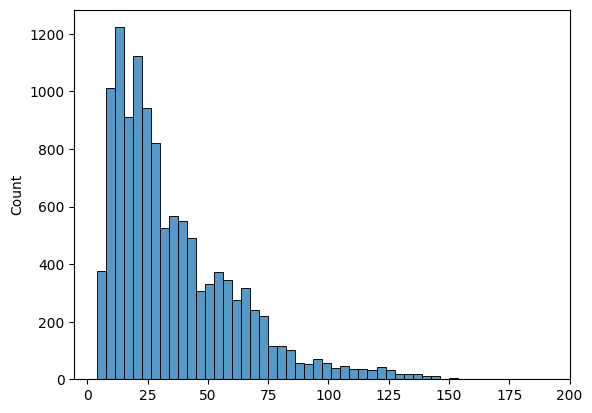

In [15]:
def tokenizer_test(batch):
  tokenized = baseline_tokenizer(
        batch['text'],
        truncation=False
    )

  # Coloca os rótulos no resultado
  tokenized['length'] = [len(tk) for tk in tokenized['input_ids']]

  return tokenized


tokenized_train = df_train.map(
    tokenizer_test,
    batched=True,
    remove_columns=['comment_id'],
    keep_in_memory=True
)

sns.histplot(tokenized_train['length'], bins=50)

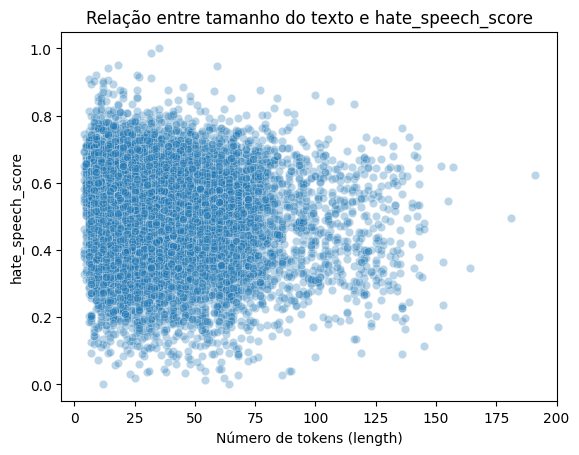

In [16]:
sns.scatterplot(
    x=tokenized_train['length'],
    y=tokenized_train['hate_speech_score'],
    alpha=0.3
)
plt.xlabel("Número de tokens (length)")
plt.ylabel("hate_speech_score")
plt.title("Relação entre tamanho do texto e hate_speech_score")
plt.show()

In [17]:
TOKEN_MAX_LENGTH = 75
BATCH_SIZE = 32

def tokenize_datasets(tokenizer,
                      datasets_dict,
                      batch_size=BATCH_SIZE,
                      token_max_length=TOKEN_MAX_LENGTH):

  def preprocess_function(samples):
      """
      Processa o dataset, tokenizando os textos.
      Também retorna os rótulos para construção dos batches.
      """

      # "Tokeniza" os textos
      tokenized = tokenizer(
          samples['text'],
          truncation=True,
          padding='max_length',
          max_length=token_max_length
      )

      # Coloca os rótulos no resultado
      tokenized['labels'] = samples['hate_speech_score']

      return tokenized

  for type, dataset in datasets_dict.items():
    shuffle = True if type == 'train' else False

    yield dataset.map(
        preprocess_function,
        batched=True,
        keep_in_memory=True #evitar problemas com cache
      ).to_tf_dataset( # Configura os datasets para o padrão que o transformer espera (ids dos tokens e máscaras de atenção)
        columns=['input_ids', 'attention_mask'],
        label_cols='labels',
        batch_size=batch_size,
        shuffle=shuffle
      )

In [18]:
dataset_train, dataset_val, dataset_test = tokenize_datasets(
    baseline_tokenizer,
    {'train': df_train, 'val': df_val, 'test': df_test}
)

Map:   0%|          | 0/11869 [00:00<?, ? examples/s]

Map:   0%|          | 0/7913 [00:00<?, ? examples/s]

Map:   0%|          | 0/7913 [00:00<?, ? examples/s]

### Cálculo de métricas no Conjunto de Validação (Baseline)

2.  (1.0) Baseado no modelo selecionado na atividade anterior, sem ajustes adicionais, calcule as métricas de Mean Absolute Error (Erro médio absoluto) - MAE, e Mean Squared Error (Erro quadrático médio) - MSE. Crie uma função que retorne os dois valores (como tupla, dicionário, ou de qualquer outra forma).


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def get_model_metrics(model, val_dataset=dataset_val):
  preds = model.predict(val_dataset)

  y_pred = preds.logits.squeeze()
  y_true = []

  for features, labels in val_dataset:
    y_true.extend(labels.numpy())

  y_true = np.array(y_true)

  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)

  return {'mae': mae, 'mse': mse}

In [20]:
baseline_metrics = get_model_metrics(baseline_model)
print(f"MAE Baseline: {baseline_metrics['mae']:.3f}")
print(f"MSE Baseline: {baseline_metrics['mse']:.3f}")

248/248 [==============================] - 7s 10ms/step
MAE Baseline: 0.417
MSE Baseline: 0.214


### Ajuste Fino (Fine-Tuning) de Modelos

3. (4.0) Efetue o ajuste fino (fine tuning) em **dois** modelos da lista apresentada no exemplo e compare-os. De preferência, teste um dos modelos mais leves (`tiny` ou `small`), e um dos mais pesados (`medium` ou `bert-base-uncased`). Caso o tempo de GPU seja um problema, é possível utilizar os dois menores apenas.</br>
- Para cada um dos modelos, experimente duas taxas de aprendizado: 0.01 e 0.00001 (embora outras taxas também possam ser exploradas). </br>
- Quais as métricas alcançadas no conjunto de validação para cada uma dessas taxas e em cada modelo? </br>
- Analise e debata as variações de desempenho observadas entre os modelos e as taxas.

In [38]:
from transformers import create_optimizer

EPOCHS = 5

def model_fit(model, lr, train_ds, val_ds, epochs=EPOCHS):
  model.layers[0].trainable = True

  total_steps = int(len(train_ds)*epochs)

  optimizer, schedule = create_optimizer(
      init_lr=lr,
      num_warmup_steps=int(0.1*total_steps),
      num_train_steps=total_steps,
      weight_decay_rate=0.01
  )

  model.compile(
      optimizer=optimizer,
      loss='mse',
      metrics=['mae']
  )

  return model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=epochs
  )

In [39]:
model_name_light = "prajjwal1/bert-small" # Escolha o modelo conforme sua necessidade
tokenizer_light = AutoTokenizer.from_pretrained(model_name_light)  # Carregar o tokenizer

dataset_train, dataset_val, dataset_test = tokenize_datasets(
    tokenizer_light,
    {'train': df_train, 'val': df_val, 'test': df_test},
    token_max_length=TOKEN_MAX_LENGTH,
    batch_size=BATCH_SIZE
)

model_light = TFAutoModelForSequenceClassification.from_pretrained(model_name_light, num_labels=1, from_pt=True, output_attentions=False)

h1 = model_fit(model_light, 1e-2, dataset_train, dataset_val)

model_light = TFAutoModelForSequenceClassification.from_pretrained(model_name_light, num_labels=1, from_pt=True, output_attentions=False)

h2 = model_fit(model_light, 1e-5, dataset_train, dataset_val)


Map:   0%|          | 0/11869 [00:00<?, ? examples/s]

Map:   0%|          | 0/7913 [00:00<?, ? examples/s]

Map:   0%|          | 0/7913 [00:00<?, ? examples/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
371/371 [==============================] - 18s 30ms/step - loss: 0.0606 - mae: 0.1873 - val_loss: 0.0695 - val_mae: 0.2255
Epoch 2/5
371/371 [==============================] - 10s 27ms/step - loss: 0.0356 - mae: 0.1508 - val_loss: 0.0426 - val_mae: 0.1767
Epoch 3/5
371/371 [==============================] - 10s 27ms/step - loss: 0.0309 - mae: 0.1408 - val_loss: 0.0201 - val_mae: 0.1131
Epoch 4/5
371/371 [==============================] - 10s 27ms/step - loss: 0.0290 - mae: 0.1355 - val_loss: 0.0209 - val_mae: 0.1189
Epoch 5/5
371/371 [==============================] - 10s 28ms/step - loss: 0.0223 - mae: 0.1204 - val_loss: 0.0201 - val_mae: 0.1149


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
371/371 [==============================] - 18s 30ms/step - loss: 0.0602 - mae: 0.1782 - val_loss: 0.0134 - val_mae: 0.0911
Epoch 2/5
371/371 [==============================] - 10s 27ms/step - loss: 0.0204 - mae: 0.1135 - val_loss: 0.0114 - val_mae: 0.0838
Epoch 3/5
371/371 [==============================] - 10s 28ms/step - loss: 0.0181 - mae: 0.1065 - val_loss: 0.0105 - val_mae: 0.0802
Epoch 4/5
371/371 [==============================] - 10s 27ms/step - loss: 0.0172 - mae: 0.1041 - val_loss: 0.0101 - val_mae: 0.0790
Epoch 5/5
371/371 [==============================] - 10s 27ms/step - loss: 0.0162 - mae: 0.1009 - val_loss: 0.0101 - val_mae: 0.0783


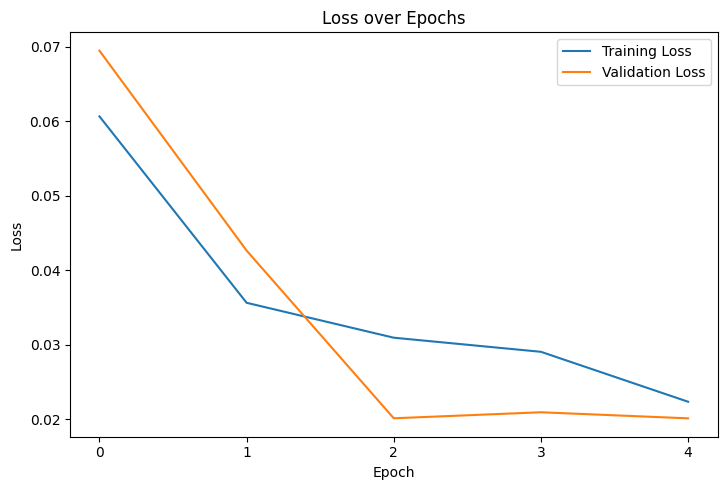

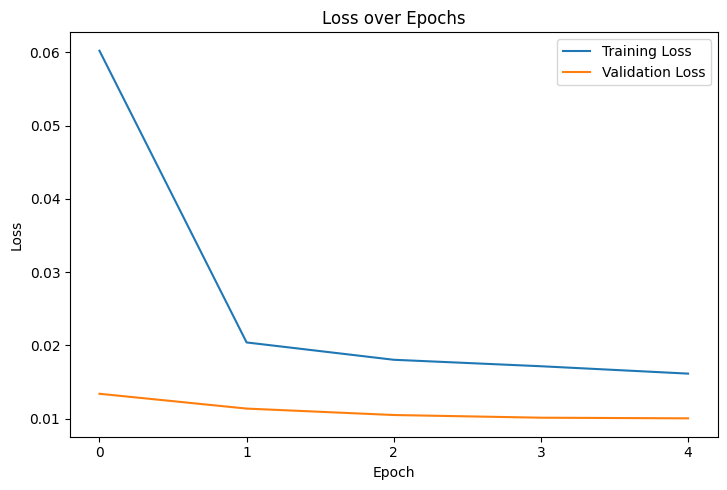

In [40]:
plot_loss(h1)
plot_loss(h2)

In [41]:
model_name_heavy = "prajjwal1/bert-medium" # Escolha o modelo conforme sua necessidade
tokenizer_heavy = AutoTokenizer.from_pretrained(model_name_heavy)  # Carregar o tokenizer

dataset_train, dataset_val, dataset_test = tokenize_datasets(
    tokenizer_heavy,
    {'train': df_train, 'val': df_val, 'test': df_test},
    token_max_length=TOKEN_MAX_LENGTH,
    batch_size=BATCH_SIZE
)

model_heavy = TFAutoModelForSequenceClassification.from_pretrained(model_name_heavy, num_labels=1, from_pt=True, output_attentions=False)

h1 = model_fit(model_heavy, 1e-2, dataset_train, dataset_val)

model_heavy = TFAutoModelForSequenceClassification.from_pretrained(model_name_heavy, num_labels=1, from_pt=True, output_attentions=False)

h2 = model_fit(model_heavy, 1e-5, dataset_train, dataset_val)

Map:   0%|          | 0/11869 [00:00<?, ? examples/s]

Map:   0%|          | 0/7913 [00:00<?, ? examples/s]

Map:   0%|          | 0/7913 [00:00<?, ? examples/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
371/371 [==============================] - 31s 53ms/step - loss: 0.1875 - mae: 0.2898 - val_loss: 0.0472 - val_mae: 0.1872
Epoch 2/5
371/371 [==============================] - 17s 47ms/step - loss: 0.0607 - mae: 0.1950 - val_loss: 0.0260 - val_mae: 0.1237
Epoch 3/5
371/371 [==============================] - 17s 47ms/step - loss: 0.0310 - mae: 0.1407 - val_loss: 0.0205 - val_mae: 0.1130
Epoch 4/5
371/371 [==============================] - 17s 47ms/step - loss: 0.0261 - mae: 0.1297 - val_loss: 0.0200 - val_mae: 0.1135
Epoch 5/5
371/371 [==============================] - 17s 47ms/step - loss: 0.0221 - mae: 0.1200 - val_loss: 0.0201 - val_mae: 0.1152


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
371/371 [==============================] - 31s 53ms/step - loss: 0.0215 - mae: 0.1147 - val_loss: 0.0102 - val_mae: 0.0788
Epoch 2/5
371/371 [==============================] - 18s 47ms/step - loss: 0.0135 - mae: 0.0916 - val_loss: 0.0096 - val_mae: 0.0763
Epoch 3/5
371/371 [==============================] - 18s 47ms/step - loss: 0.0116 - mae: 0.0850 - val_loss: 0.0091 - val_mae: 0.0741
Epoch 4/5
371/371 [==============================] - 17s 47ms/step - loss: 0.0104 - mae: 0.0806 - val_loss: 0.0090 - val_mae: 0.0735
Epoch 5/5
371/371 [==============================] - 18s 47ms/step - loss: 0.0098 - mae: 0.0776 - val_loss: 0.0089 - val_mae: 0.0732


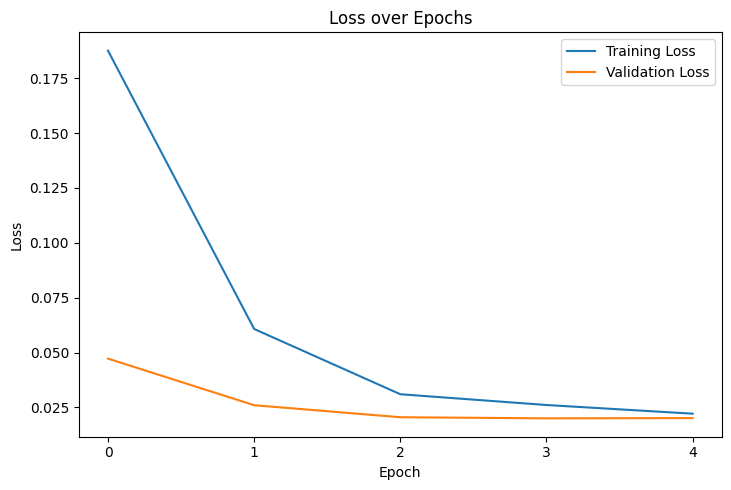

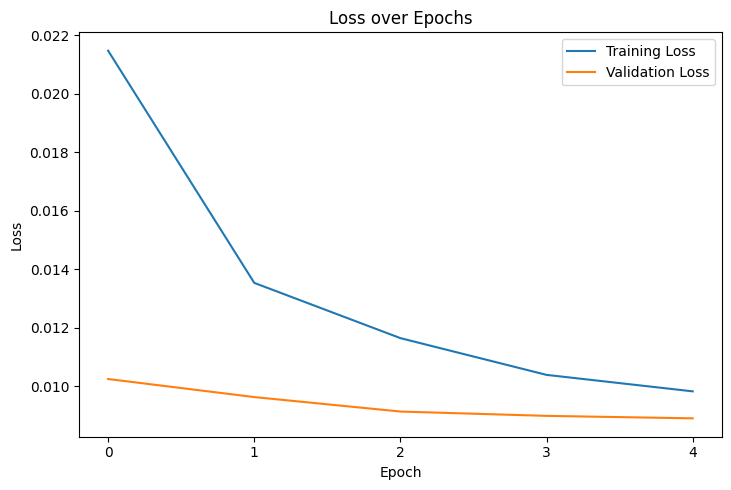

In [42]:
plot_loss(h1)
plot_loss(h2)

Discussão:
Testamos um total de 4 cenários. Avaliamos os modelos bert-medium e o bert-small, cada um com taxa de aprendizado de 1e-2 e 1e-5. Em todos não observamos indícios de overfitting para os modelos. No treinamento do bert-small com taxa de aprendizado de 1e-2, observamos um salto na Loss de validação para 2 épocas de trainamento, o que nos chamou atenção. Porém esse valor voltou ao comportamento esperado para as épocas seguintes, afastando nossa preocupação de overfitting para essa configuração de treinamento.

Comparando as diferentes taxas de aprendizado, tanto o medium quanto o small obtiveram melhor performance com o valor de 1e-5 em comparação com o valor de 1e-2.
Ao comparar o medium e o small com taxa de aprendizado de 1e-5, podemos observar que o medium possui melhor performance. Porém, ao analisar no detalhe o valor de Loss em cada uma dessas configurações de modelos, vemos que na época 5 do modelo medium tivemos uma loss de 0.0092, enquanto no small tivemos 0.0100, uma diferença muito pequena entre os modelos. Ao comparar o tempo de treinamento de cada época, vemos que o small levou por volta de 18 segundos nas épocas finais de treinamento, enquanto o medium precisou de 30 segundos. Além disso, vale pontuar que o small requer menos recursos computacionais do que o medium.

Levando em consideração a performance equivalente entre o medium e o small, o melhor tempo de execução e o menor requisito computacional, podemos concluir que o small teve melhor desempenho que o medium.

### Avaliação do Modelo com Melhor Desempenho no Conjunto de teste
4. (2.0) Utilize o modelo com melhor desempenho no conjunto de teste e analise os resultados. Discuta brevemente os principais desafios enfrentados durante o treinamento do modelo e as soluções adotadas para superá-los. Além disso, reveja os hiperparâmetros escolhidos e reflita sobre o impacto potencial deles no desempenho do modelo.

In [58]:
model_name_light = "prajjwal1/bert-small"
MODEL_DIR = "/content/drive/MyDrive/mdc_checkpoints/hate_bert_small_tf"

if os.path.exists(MODEL_DIR):
  best_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
  best_model = TFAutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
else:
  best_tokenizer = AutoTokenizer.from_pretrained(model_name_light)
  dataset_train, dataset_val, dataset_test = tokenize_datasets(
      tokenizer_light,
      {'train': df_train, 'val': df_val, 'test': df_test},
      token_max_length=TOKEN_MAX_LENGTH,
      batch_size=BATCH_SIZE
  )
  best_model = TFAutoModelForSequenceClassification.from_pretrained(model_name_light, num_labels=1, from_pt=True, output_attentions=False)
  model_fit(best_model, 1e-5, dataset_train, dataset_val)
  best_model.save_pretrained(MODEL_DIR)
  best_tokenizer.save_pretrained(MODEL_DIR)

Some layers from the model checkpoint at /content/drive/MyDrive/mdc_checkpoints/hate_bert_small_tf were not used when initializing TFBertForSequenceClassification: ['dropout_309']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at /content/drive/MyDrive/mdc_checkpoints/hate_bert_small_tf.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further trai

In [59]:
test_dataset_metrics = get_model_metrics(best_model, dataset_test)
print(f"MAE Test: {test_dataset_metrics['mae']:.3f}")
print(f"MSE Test: {test_dataset_metrics['mse']:.3f}")

248/248 [==============================] - 3s 9ms/step
MAE Test: 0.079
MSE Test: 0.010


#### Discussão:

Obtivemos um MSE de 0.010 no conjunto de teste, um resultado bem similar ao observado com o conjunto de dados de validação. É um bom valor, o que indica que o modelo não está super ajustado ao conjunto de dados de treinamento, pois foi capaz de gerar um pequeno erro ao testar prever um novo conjunto de dados (o conjunto de teste).
Ao longo do desenvolvimento do modelo notamos longos tempos para o treinamento. Tentamos aumentar a quantidade de épocas utilizadas no treinamento com até 10 épocas, mas o resultado foi bem parecido com o 5 épocas, apenas com um tempo muito maior para o treinamento, mesmo configurando o ambiente para uso de GPU.

Além disso, o uso do max_length de 75 se mostrou uma boa escolha. Mesmo com um quantidade razoável de amostras com uma quantidade de tokens superior a 75, o modelo foi capaz de gerar um erro médio absoluto muito pequeno.

### Análise do Mecanismo de Atenção com BertViz
5. (2.0) Use a ferramenta BertViz (github.com/jessevig/bertviz) para explorar os pesos do modelo selecionado na atividade anterior. Ao inspecionar o comportamento desse modelo, especificamente o transformador e seu mecanismo de atenção, quais padrões se tornam evidentes? Realize uma análise crítica desses padrões, destacando como eles podem impactar a interpretação e a performance do modelo.


In [73]:
from bertviz import model_view, head_view
import torch

# usando analise anterior para obter textos exemplo
text_high_hate, high_label = high_samples[0]['text'], high_samples[0]['hate_speech_score']
text_low_hate, low_label = low_samples[0]['text'], low_samples[0]['hate_speech_score']

def get_bertviz_data(text, tokenizer, model):
    inputs = tokenizer.encode_plus(
        text,
        return_tensors='tf',
        add_special_tokens=True,
        truncation=True,
        padding='max_length',
        max_length=TOKEN_MAX_LENGTH
      )

    input_ids = inputs['input_ids']
    attention_mask = inputs['attention_mask']

    outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
    tf_attentions = outputs.attentions

    torch_attentions = tuple(torch.from_numpy(att.numpy()) for att in tf_attentions)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].numpy())
    return torch_attentions, tokens

attentions_high, tokens_high = get_bertviz_data(text_high_hate, best_tokenizer, best_model)
attentions_low, tokens_low = get_bertviz_data(text_low_hate, best_tokenizer, best_model)

In [74]:
print(text_low_hate, low_label)
head_view(attentions_low,tokens_low)

Fellow trans girl here! Love and support confirmed! 0.0


<IPython.core.display.Javascript object>

In [72]:
print(text_high_hate, high_label)
head_view(attentions_high,tokens_high)

Dig burn PITS and treat them THE INVADING NAZIS ALL OVER EUROPE. ESPECIALLY THE WOMEN DON'T LET THEM BREED HERE MR. PRESIDENT. FIRING SQUADS SO I CAN VOLUNTEER 1.0


<IPython.core.display.Javascript object>

Discussão: